# RandomWalks

In [1]:
import networkx as nx

In [2]:
G = nx.karate_club_graph()

In [3]:
print('Number of nodes:', len(G.nodes))

Number of nodes: 34


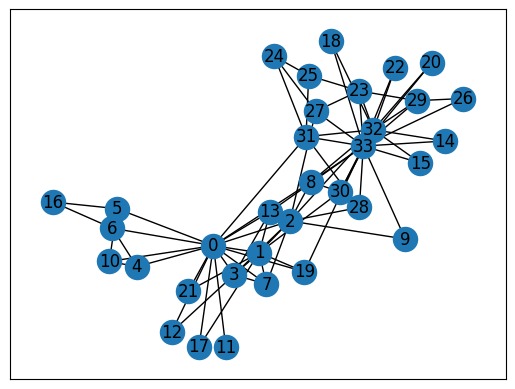

In [4]:
nx.draw_networkx(G)

Plot the graphs with labels

In [5]:
labels = []
for i in G.nodes:
    club_names = G.nodes[i]['club']
    labels.append(1 if club_names == 'Mr. Hi' else 0) #There are two clubs in the graph, 'Mr. Hi' and 'Officer'. We will use 1 to represent 'Mr. Hi' and 0 to represent 'Officer'.

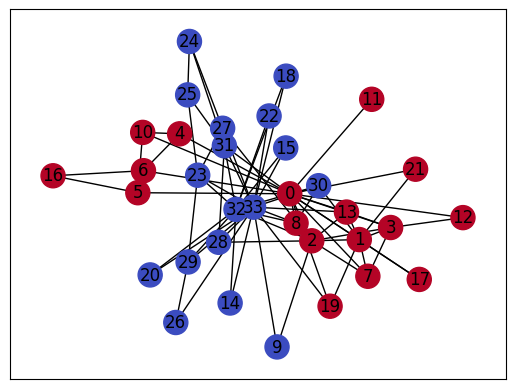

In [6]:
layout_pos = nx.spring_layout(G) #The spring layout is a force-directed layout algorithm that positions nodes in a way that minimizes edge crossings and distributes nodes evenly in the space. It simulates a physical system where nodes repel each other and edges act like springs, pulling connected nodes together. This results in a visually appealing layout that can help reveal the structure of the graph.
nx.draw_networkx(G, pos=layout_pos, node_color=labels, cmap='coolwarm')

**Perform node embeddings using DeepWalk**

In [7]:
from karateclub import DeepWalk

ModuleNotFoundError: No module named 'karateclub'

## USE PyGeomtric for DeepWalk (Karate club is older)

In [2]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.11.0+cpu
2.7.0


In [5]:
%pip install gensim

  Using cached gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   --- ------------------------------------ 1.8/24.4 MB 7.7 MB/s eta 0:00:03
   ------ --------------------------------- 3.7/24.4 MB 8.1 MB/s eta 0:00:03
   --------- ------------------------------ 5.8/24.4 MB 8.6 MB/s eta 0:00:03
   ------------ --------------------------- 7.6/24.4 MB 8.9 MB/s eta 0:00:02
   --------------- ------------------------ 9.7/24.4 MB 9.0 MB/s eta 0:00:02
   ------------------ --------------------- 11.5/24.4 MB 9.0 MB/s eta 0:00:02
   ---------------------- ----------------- 13.6/24.4 MB 9.1 MB/s eta 0:00:02
   ------------------------ --------------- 15.2/24.4 MB 9.1 MB/s eta 0:00:02
   -------------------------- ------------- 16.3/24.4 MB 8.7 MB/s eta 0:00:01
   ------------------------------ --------- 18.4/24.4 MB 8.5 MB/s eta 0:00:01
   ----------

In [6]:
"""
=========================================================
DeepWalk from Scratch using PyTorch Geometric
=========================================================

Pipeline:

1. Create Graph using PyTorch Geometric
2. Convert edge_index -> Adjacency List
3. Perform Random Walks
4. Treat walks as sentences
5. Train Word2Vec (Skip-Gram)
6. Obtain Node Embeddings

Author: Learning Version
"""

# ======================================================
# STEP 1 : Import Libraries
# ======================================================

import random
from collections import defaultdict

import torch
from torch_geometric.data import Data

from gensim.models import Word2Vec


# ======================================================
# STEP 2 : Create a Graph
# ======================================================
#
# Graph Structure:
#
#         0
#        / \
#       /   \
#      1-----2
#       \
#        \
#         3
#
# Undirected Edges:
#
# 0-1
# 0-2
# 1-2
# 1-3
#
# PyTorch Geometric stores edges as directed,
# therefore every undirected edge is stored twice.
# ======================================================

edge_index = torch.tensor([
    [0, 1, 0, 2, 1, 2, 1, 3],   # Source nodes
    [1, 0, 2, 0, 2, 1, 3, 1]    # Destination nodes
], dtype=torch.long)

# Create graph object
data = Data(edge_index=edge_index)

print("="*60)
print("Graph Information")
print("="*60)
print(data)
print("Number of Nodes :", data.num_nodes)
print("Number of Edges :", data.num_edges)


# ======================================================
# STEP 3 : Convert edge_index into Adjacency List
# ======================================================
#
# edge_index is not convenient for random walks.
#
# Convert:
#
# tensor([[0,1,0,2,...],
#         [1,0,2,0,...]])
#
# Into:
#
# {
#   0:[1,2],
#   1:[0,2,3],
#   2:[0,1],
#   3:[1]
# }
# ======================================================

adjacency = defaultdict(list)

# edge_index has two rows:
#
# Row 0 -> source
# Row 1 -> destination
#
sources = data.edge_index[0]
destinations = data.edge_index[1]

for src, dst in zip(sources.tolist(), destinations.tolist()):
    adjacency[src].append(dst)

print("\n")
print("="*60)
print("Adjacency List")
print("="*60)

for node in adjacency:
    print(f"Node {node} --> {adjacency[node]}")


# ======================================================
# STEP 4 : Define Random Walk Function
# ======================================================
#
# Example:
#
# Start = 0
#
# Possible Walk:
#
# 0 → 2 → 1 → 3 → 1 → 0
#
# ======================================================

def random_walk(adjacency, start_node, walk_length):

    # Store the path
    walk = [start_node]

    current_node = start_node

    # We already have first node,
    # so generate remaining nodes.
    for _ in range(walk_length - 1):

        neighbors = adjacency[current_node]

        # Stop if isolated node
        if len(neighbors) == 0:
            break

        # Randomly choose one neighbor
        next_node = random.choice(neighbors)

        # Add to walk
        walk.append(next_node)

        # Move to next node
        current_node = next_node

    return walk


# ======================================================
# STEP 5 : Test Single Random Walk
# ======================================================

print("\n")
print("="*60)
print("Single Random Walk")
print("="*60)

walk = random_walk(
    adjacency=adjacency,
    start_node=0,
    walk_length=6
)

print("Walk :", walk)


# ======================================================
# STEP 6 : Generate Many Random Walks
# ======================================================
#
# DeepWalk generates multiple walks
# from every node.
#
# ======================================================

num_walks = 5       # Walks per node
walk_length = 6

walks = []

for node in range(data.num_nodes):

    for _ in range(num_walks):

        walk = random_walk(
            adjacency,
            start_node=node,
            walk_length=walk_length
        )

        walks.append(walk)


print("\n")
print("="*60)
print("Generated Walks")
print("="*60)

for walk in walks:
    print(walk)


# ======================================================
# STEP 7 : Convert Walks into Sentences
# ======================================================
#
# Word2Vec expects words.
#
# Convert:
#
# [0,2,1,3]
#
# Into:
#
# ['0','2','1','3']
#
# ======================================================

sentences = []

for walk in walks:

    sentence = []

    for node in walk:
        sentence.append(str(node))

    sentences.append(sentence)

print("\n")
print("="*60)
print("Sentences for Word2Vec")
print("="*60)

for sentence in sentences[:5]:
    print(sentence)


# ======================================================
# STEP 8 : Train Word2Vec
# ======================================================
#
# Skip-Gram (sg=1)
#
# DeepWalk uses Skip-Gram.
#
# ======================================================

model = Word2Vec(
    sentences=sentences,

    # Dimension of embedding
    vector_size=16,

    # Context window
    window=2,

    # Use every node
    min_count=0,

    # Skip-Gram
    sg=1,

    # Training epochs
    epochs=100,

    # Single CPU
    workers=1
)

print("\n")
print("="*60)
print("Word2Vec Training Completed")
print("="*60)


# ======================================================
# STEP 9 : Get Node Embeddings
# ======================================================

print("\n")
print("="*60)
print("Node Embeddings")
print("="*60)

for node in range(data.num_nodes):

    embedding = model.wv[str(node)]

    print(f"\nNode {node}")
    print(embedding)


# ======================================================
# STEP 10 : Similar Nodes
# ======================================================

print("\n")
print("="*60)
print("Most Similar Nodes")
print("="*60)

for node in range(data.num_nodes):

    print(f"\nNode {node}")

    similar = model.wv.most_similar(str(node), topn=3)

    for neighbor, score in similar:

        print(f"{neighbor:>5}  Similarity = {score:.4f}")


# ======================================================
# STEP 11 : Access Single Embedding
# ======================================================

embedding = model.wv["0"]

print("\n")
print("="*60)
print("Embedding of Node 0")
print("="*60)

print(embedding)

print("\nEmbedding Dimension :", len(embedding))

Graph Information
Data(edge_index=[2, 8])
Number of Nodes : 4
Number of Edges : 8


Adjacency List
Node 0 --> [1, 2]
Node 1 --> [0, 2, 3]
Node 2 --> [0, 1]
Node 3 --> [1]


Single Random Walk
Walk : [0, 2, 1, 0, 1, 0]


Generated Walks
[0, 1, 0, 1, 3, 1]
[0, 1, 2, 1, 2, 0]
[0, 1, 0, 1, 0, 2]
[0, 2, 1, 2, 0, 1]
[0, 1, 3, 1, 0, 1]
[1, 0, 1, 2, 0, 1]
[1, 2, 0, 1, 0, 2]
[1, 0, 1, 2, 0, 2]
[1, 3, 1, 2, 1, 2]
[1, 2, 0, 1, 3, 1]
[2, 0, 2, 0, 2, 0]
[2, 1, 2, 0, 1, 0]
[2, 0, 1, 2, 1, 0]
[2, 1, 2, 0, 1, 3]
[2, 0, 1, 3, 1, 2]
[3, 1, 2, 1, 3, 1]
[3, 1, 3, 1, 0, 2]
[3, 1, 0, 1, 3, 1]
[3, 1, 3, 1, 2, 0]
[3, 1, 0, 2, 1, 3]


Sentences for Word2Vec
['0', '1', '0', '1', '3', '1']
['0', '1', '2', '1', '2', '0']
['0', '1', '0', '1', '0', '2']
['0', '2', '1', '2', '0', '1']
['0', '1', '3', '1', '0', '1']


Word2Vec Training Completed


Node Embeddings

Node 0
[ 0.03028242  0.00842256 -0.05828425 -0.05109224  0.04007615  0.02063212
  0.06521359  0.01389469  0.03315273 -0.03169345 -0.00339654  0.04204318
 -

d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])


**1. Graph Information**

```text
Data(edge_index=[2, 8])
Number of Nodes : 4
Number of Edges : 8
```

**What happened?**

We created

```text
      0
     / \
    /   \
   1-----2
    \
     \
      3
```

Undirected edges are

```text
0-1
0-2
1-2
1-3
```

Since PyG stores **directed edges**, it internally stores

```text
0→1
1→0

0→2
2→0

1→2
2→1

1→3
3→1
```

Total = **8 directed edges**

Hence

```text
Data(edge_index=[2,8])
```

means

- 2 rows
- 8 edge columns

---

**2. Adjacency List**

```text
Node 0 --> [1, 2]
Node 1 --> [0, 2, 3]
Node 2 --> [0, 1]
Node 3 --> [1]
```

We converted

```python
edge_index
```

into a dictionary.

Instead of

```text
edge_index

0→1
1→0
0→2
...
```

we now have

```text
0
↓
Neighbors = 1,2

1
↓
Neighbors = 0,2,3

2
↓
Neighbors = 0,1

3
↓
Neighbors = 1
```

Random walk algorithms use this because finding neighbors is now very fast.

---

**3. Single Random Walk**

```
Walk :
[0, 2, 1, 0, 1, 0]
```

Let's simulate it.

**Start**

```
Current node = 0
```

Neighbors:

```
1
2
```

Suppose random chooses

```
2
```

Walk becomes

```
0 → 2
```

---

Current node

```
2
```

Neighbors

```
0
1
```

Suppose choose

```
1
```

Walk

```
0 → 2 → 1
```

---

Current

```
1
```

Neighbors

```
0
2
3
```

Suppose choose

```
0
```

Walk

```
0 → 2 → 1 → 0
```

Continue...

Eventually

```
0 → 2 → 1 → 0 → 1 → 0
```

Nothing magical.

It is literally a person randomly walking through the graph.

---

**4. Generated Walks**

```
[0,1,0,1,3,1]
[0,1,2,1,2,0]
...
```

Remember we used

```python
num_walks = 5
```

We have

```
4 nodes
```

Therefore

```
Node 0
↓

5 walks

Node 1
↓

5 walks

Node 2
↓

5 walks

Node 3
↓

5 walks
```

Total

```
4 × 5 = 20 walks
```

Exactly what you got.

---

Notice the first five walks all begin with

```
0
```

because they are generated starting from node 0.

Next five

```
1
```

Then

```
2
```

Then

```
3
```

---

**Why Generate So Many Walks?**

Suppose we generated only

```
0→1→2→1→3
```

That is just one observation.

Maybe

```
0
```

never visits

```
2
```

again.

Multiple walks explore different neighborhoods.

DeepWalk therefore builds a richer picture of the graph.

---

**5. Sentences**

```
['0','1','0','1','3','1']
```

This is the biggest trick of DeepWalk.

Before

```
[0,1,0,1,3,1]
```

Python integers.

Word2Vec expects

```
Words
```

So we convert

```
0
```

into

```
"0"
```

Now Word2Vec thinks

```
0

1

2

3
```

are simply words.

It has **no idea these are graph nodes.**

---

Think like this

Original NLP

```
I love AI
```

DeepWalk

```
0 1 0 1 3 1
```

Exactly the same algorithm.

---

**6. Word2Vec Training Completed**

```
Word2Vec Training Completed
```

Now Word2Vec has learned vectors.

Instead of

```
Node 0
```

being

```
0
```

it becomes

```
[0.03
0.008
...
]
```

---

**7. Node Embeddings**

```
Node 0

[0.030
0.008
...
]
```

This vector has

```
16 numbers
```

because we specified

```python
vector_size = 16
```

Every node now has

```
16-dimensional representation
```

Instead of

```
Node 0
```

the model now thinks

```
Node 0 =
(0.03,
0.008,
-0.058,
...)
```

These numbers themselves don't have a direct human interpretation. What matters is that **nodes with similar graph contexts end up with similar vectors**.

---

**8. Most Similar Nodes**

```
Node 0

3 → 0.5919

2 → 0.2048

1 → 0.0960
```

This uses

```
Cosine Similarity
```

between embeddings.

For example

```
Embedding(0)

vs

Embedding(3)
```

Suppose

```
0 = [1,2]

3 = [2,4]
```

They point in almost the same direction.

Cosine similarity

```
≈ 1
```

means

```
very similar
```

---

**Why is Node 3 most similar to Node 0?**

Good observation!

Actually,

```
3
```

is only connected to

```
1
```

and

```
0
```

is connected to

```
1
```

They often appear near each other through node 1 in the random walks:

```
0 → 1 → 3
3 → 1 → 0
```

Since the graph is tiny and the training data is very limited (only 20 walks), Word2Vec has learned that **0 and 3 share similar contexts**.

On a real graph with hundreds or thousands of nodes, these similarities become much more meaningful.

---

**9. Embedding Dimension**

```
Embedding Dimension : 16
```

Exactly because

```python
vector_size = 16
```

If you changed

```python
vector_size = 64
```

then each node would have

```
64 numbers
```

---

**10. The Warning**

```
Unable to accurately infer num_nodes...
```

This is **not an error**.

It happens because your graph only contains

```python
edge_index
```

No node features (`x`) were provided.

PyG estimates the number of nodes as:

```python
max(edge_index) + 1
```

For your graph:

```
max node ID = 3
```

So it infers

```
4 nodes
```

However, PyG recommends explicitly setting the number of nodes:

```python
data = Data(
    edge_index=edge_index,
    num_nodes=4
)
```

This removes the warning and is good practice, especially if you have isolated nodes that don't appear in any edge.

---

# Node2Vec 
(Biased Random Walk)